In [24]:
#Importovanje potrebnih biblioteka
from tensorflow import keras 
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
from datetime import datetime

In [25]:
# Ucitavanje .csv fajla
df = pd.read_csv('novi-sad-air-quality.csv', delimiter=",")
Ns = pd.DataFrame(df)
print(Ns)
Ns.dtypes

            date pm25 pm10 o3  no2 so2   co
0       2026/1/1   46            9   2    4
1       2026/1/2   41           13   2    5
2       2026/1/3   39           13   2    5
3       2026/1/4   59           14   2    5
4       2026/1/5   75           12   2    5
...          ...  ...  ... ..  ...  ..  ...
2218   2025/12/4                 8   3    2
2219  2025/12/20                13   4    4
2220  2021/12/26                13   5   11
2221  2021/12/27                10   5   13
2222    2020/5/7                12   2    2

[2223 rows x 7 columns]


date    object
pm25    object
pm10    object
o3      object
no2     object
so2     object
co      object
dtype: object

In [26]:
#Promena datatype u odgovarajuci format
Ns[['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']] = Ns[['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']].astype("string")
Ns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2223 entries, 0 to 2222
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    2223 non-null   object
 1   pm25    2223 non-null   string
 2   pm10    2223 non-null   string
 3   o3      2223 non-null   string
 4   no2     2223 non-null   string
 5   so2     2223 non-null   string
 6   co      2223 non-null   string
dtypes: object(1), string(6)
memory usage: 121.7+ KB


In [27]:
#Promena datatype u odgovarajuci format
Ns['pm25'] = pd.to_numeric(Ns['pm25'], errors='coerce')
Ns['pm10'] = pd.to_numeric(Ns['pm10'], errors='coerce')
Ns['o3'] = pd.to_numeric(Ns['o3'], errors='coerce')
Ns['no2'] = pd.to_numeric(Ns['no2'], errors='coerce')
Ns['so2'] = pd.to_numeric(Ns['so2'], errors='coerce')
Ns['co'] = pd.to_numeric(Ns['co'], errors='coerce')
Ns.info()
Ns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2223 entries, 0 to 2222
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    2223 non-null   object
 1   pm25    2208 non-null   Int64 
 2   pm10    2165 non-null   Int64 
 3   o3      5 non-null      Int64 
 4   no2     2199 non-null   Int64 
 5   so2     2187 non-null   Int64 
 6   co      2168 non-null   Int64 
dtypes: Int64(6), object(1)
memory usage: 134.7+ KB


,date,pm25,pm10,o3,no2,so2,co
0,2026/1/1,46,<NA>,<NA>,9,2,4
1,2026/1/2,41,<NA>,<NA>,13,2,5
2,2026/1/3,39,<NA>,<NA>,13,2,5
3,2026/1/4,59,<NA>,<NA>,14,2,5
4,2026/1/5,75,<NA>,<NA>,12,2,5
...,...,...,...,...,...,...,...
2218,2025/12/4,<NA>,<NA>,<NA>,8,3,2
2219,2025/12/20,<NA>,<NA>,<NA>,13,4,4
2220,2021/12/26,<NA>,<NA>,<NA>,13,5,11
2221,2021/12/27,<NA>,<NA>,<NA>,10,5,13


In [28]:
#Postavljanje date kolone na mesto index
Ns.index = pd.to_datetime(Ns["date"])
Ns.sort_index(inplace=True)
Ns.drop(columns=["date","o3"], inplace=True)
Ns

,pm25,pm10,no2,so2,co
date,,,,,
2019-12-14,<NA>,47,28,11,14
2019-12-15,89,86,37,10,19
2019-12-16,141,89,38,11,21
2019-12-17,158,93,35,11,23
2019-12-18,164,65,19,6,13
...,...,...,...,...,...
2026-01-16,130,<NA>,7,5,6
2026-01-17,52,<NA>,5,4,6
2026-01-18,71,<NA>,7,10,6


In [29]:
#popunjavanje nedostajucih vrednosti
Ns.ffill(inplace = True)
Ns.bfill(inplace = True)
Ns.head(20)

,pm25,pm10,no2,so2,co
date,,,,,
2019-12-14,89,47,28,11,14
2019-12-15,89,86,37,10,19
2019-12-16,141,89,38,11,21
2019-12-17,158,93,35,11,23
2019-12-18,164,65,19,6,13
2019-12-19,155,42,17,8,9
2019-12-20,85,25,11,8,7
2019-12-21,59,15,8,7,7
2019-12-22,44,6,7,5,7


In [30]:
# Kreiranje AQI kolone kao indeks zagadjenosti vazduha
Ns['AQI'] = Ns[['pm25','pm10','no2','so2','co']].max(axis=1)
Ns


,pm25,pm10,no2,so2,co,AQI
date,,,,,,
2019-12-14,89,47,28,11,14,89
2019-12-15,89,86,37,10,19,89
2019-12-16,141,89,38,11,21,141
2019-12-17,158,93,35,11,23,158
2019-12-18,164,65,19,6,13,164
...,...,...,...,...,...,...
2026-01-16,130,24,7,5,6,130
2026-01-17,52,24,5,4,6,52
2026-01-18,71,24,7,10,6,71


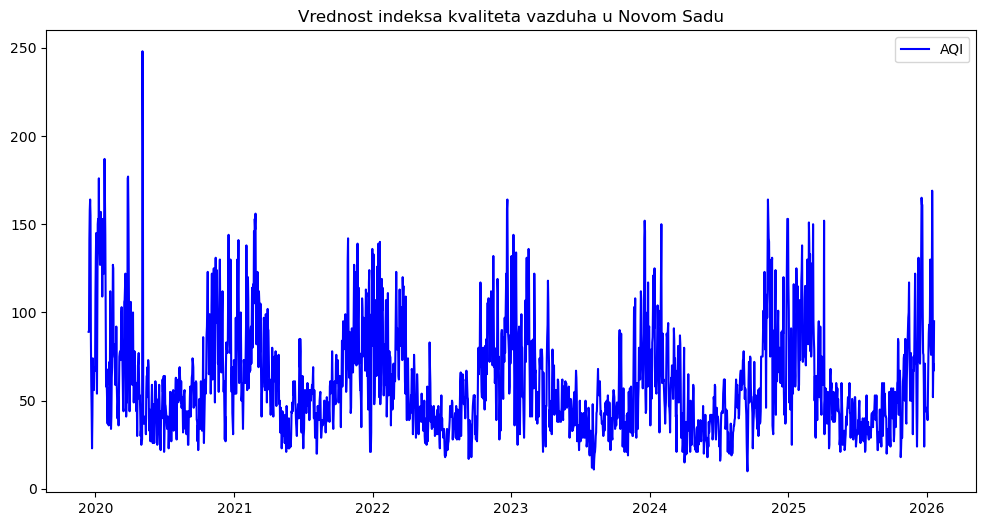

In [31]:
#Grafik za prikaz AQI
plt.figure(figsize=(12,6))
plt.plot(Ns.index, Ns['AQI'], label = "AQI", color = "blue")
plt.title("Vrednost indeksa kvaliteta vazduha u Novom Sadu")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Matrica korelacije')

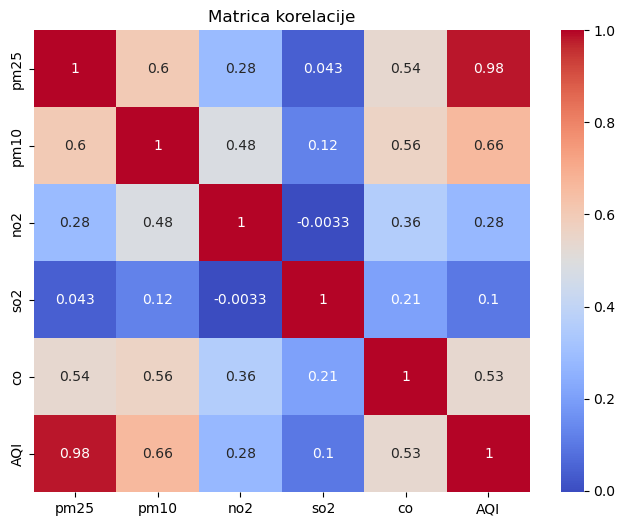

In [32]:
#Matrica korelacije
plt.figure(figsize=(8,6))
sns.heatmap(Ns.corr(), annot=True, cmap="coolwarm")
plt.title("Matrica korelacije")

In [33]:
#Kreiranje trening data
AQI_val = Ns.filter(["AQI"])
dataset = AQI_val.values
training_data_len = int(np.ceil(len(dataset)*0.98))

In [34]:
# Standradizacija vrednosti za unos u LSTM model
scaler= StandardScaler()
scaled_data= scaler.fit_transform(dataset)

training_data = scaled_data[:training_data_len]

X_train, y_train = [], []

In [35]:
# Kreiranje prozora(window) za posmatranje vrednosti unutar modela
for i in range(60, len(training_data)):
    X_train.append(training_data[i-60:i, 0])
    y_train.append(training_data[i,0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [36]:
# Kreiranje modela
model = keras.models.Sequential()
# Kreiranje 1. nivoa
model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)))
# Kreiranje 2. nivoa
model.add(keras.layers.LSTM(64, return_sequences=False))
# Kreiranje 3. nivoa
model.add(keras.layers.Dense(128, activation="relu"))
# Kreiranje 4. nivoa
model.add(keras.layers.Dropout(0.5))
# Kreiranje konacnog nivoa
model.add(keras.layers.Dense(1))

model.summary()
model.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])

E:\anaconda\envs\python_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#pokretanje modela
training = model.fit(X_train, y_train, epochs=20, batch_size=32)

test_data = scaled_data[training_data_len - 60:]
X_test, y_test = [], dataset[training_data_len:]


for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1 ))


Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.5679 - root_mean_squared_error: 0.7668
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.5313 - root_mean_squared_error: 0.7323
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.4969 - root_mean_squared_error: 0.6899
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4570 - root_mean_squared_error: 0.6462
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.4370 - root_mean_squared_error: 0.6088
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4311 - root_mean_squared_error: 0.6052
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4296 - root_mean_squared_error: 0.5999
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4264 - root_mean_squared_error: 0.5956
Epoch 9/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4267 - root_mean_squared_error: 0.5998
Epoch 10/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4201 - root_mean_squared_error: 0.6008

In [38]:
# Vrsenje predvidjana vrednosti
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


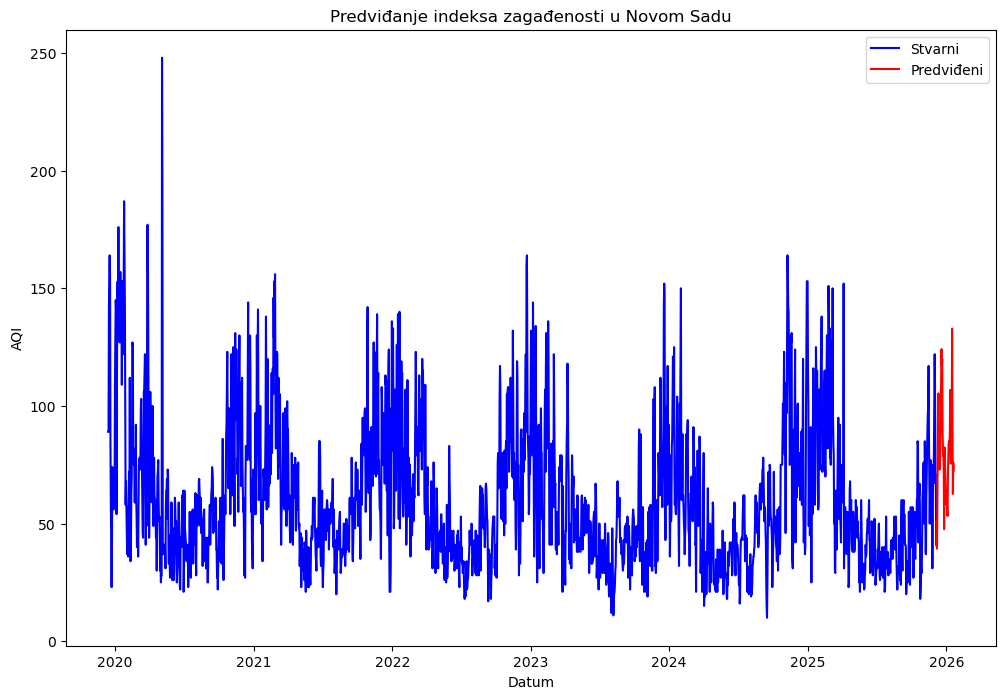

In [39]:
# Prikaz rezultata na grafikonu
train = Ns[:training_data_len]
test =  Ns[training_data_len:]

test = test.copy()

test['Predictions'] = predictions

plt.figure(figsize=(12,8))
plt.plot(train.index, train['AQI'], label="Stvarni", color='blue')
plt.plot(test.index, test['Predictions'], label="Predviđeni", color='red')
plt.title("Predviđanje indeksa zagađenosti u Novom Sadu")
plt.xlabel("Datum")
plt.ylabel("AQI")
plt.legend()
plt.show()

In [40]:
# Prikaz konkretnih predvidjenih vrednosti
test['Predictions']


date
2025-12-06     50.913280
2025-12-07     39.323830
2025-12-08     53.802090
2025-12-09     80.912201
2025-12-10     99.228706
2025-12-11    105.350212
2025-12-12     73.184341
2025-12-13     76.772949
2025-12-14     72.972038
2025-12-15     73.634193
2025-12-16     86.210632
2025-12-17     91.816704
2025-12-18    110.292450
2025-12-19    124.131874
2025-12-20    117.080231
2025-12-21    119.975655
2025-12-22     89.061714
2025-12-23     78.817741
2025-12-24     80.880493
2025-12-25     70.676277
2025-12-26     47.647022
2025-12-27     82.389206
2025-12-28     77.172943
2025-12-31     58.140491
2026-01-01     59.715294
2026-01-02     60.343822
2026-01-03     55.205582
2026-01-04     53.222202
2026-01-05     70.914215
2026-01-06     78.059044
2026-01-07     84.298813
2026-01-08     85.280258
2026-01-09     80.428963
2026-01-10     88.648132
2026-01-11    106.810539
2026-01-12     75.521240
2026-01-13     75.567017
2026-01-14     99.059547
2026-01-15     90.122337
2026-01-16    132.88

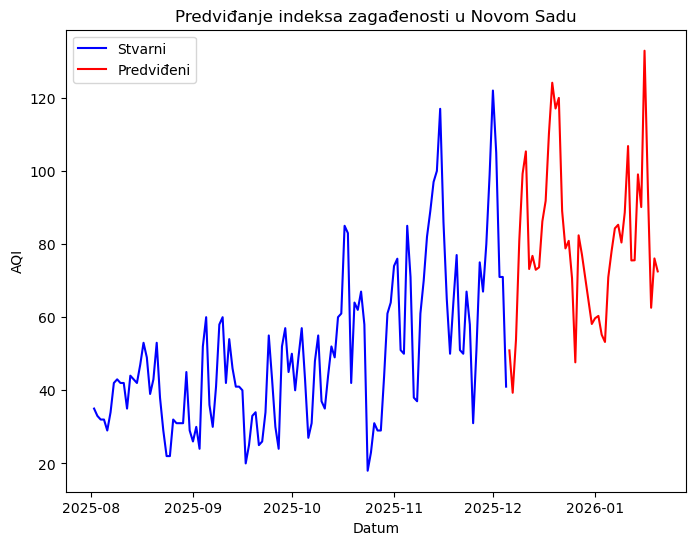

In [41]:
# Kreiranje manjeg i vidljivijeg grafikona
train = Ns.loc[(Ns.index > datetime(2025,8,1)) & (Ns.index < datetime(2025,12,6))]
test =  Ns[training_data_len:]

test = test.copy()

test['Predictions'] = predictions

plt.figure(figsize=(8,6))
plt.plot(train.index, train['AQI'], label="Stvarni", color='blue')
plt.plot(test.index, test['Predictions'], label="Predviđeni", color='red')
plt.title("Predviđanje indeksa zagađenosti u Novom Sadu")
plt.xlabel("Datum")
plt.ylabel("AQI")
plt.legend()
plt.show()

In [42]:
Prognoza_Ns = pd.DataFrame(test['Predictions'])
Prognoza_Ns.to_csv('prognoza_novisad.csv')

In [43]:
Prognoza_Ns['Predictions'] = Prognoza_Ns['Predictions'].round(0).astype(int)
Prognoza_Ns

,Predictions
date,
2025-12-06,51
2025-12-07,39
2025-12-08,54
2025-12-09,81
2025-12-10,99
2025-12-11,105
2025-12-12,73
2025-12-13,77
2025-12-14,73


In [44]:
Prognoza_Ns['Predictions'].mean()

np.float64(81.0)